# Crop Handwriting Image into Lines
Each section below is a **separate attempt** with its own imports and cells.

- Input: `whole image/WhatsApp Image 2026-04-13 at 12.40.53.jpeg`
- Output: `cropped image to lines/`

---
## Attempt 1 - Horizontal Projection Profile (Row Sum)
Sum dark pixels per row. Valleys (low sum) between lines = cut points.

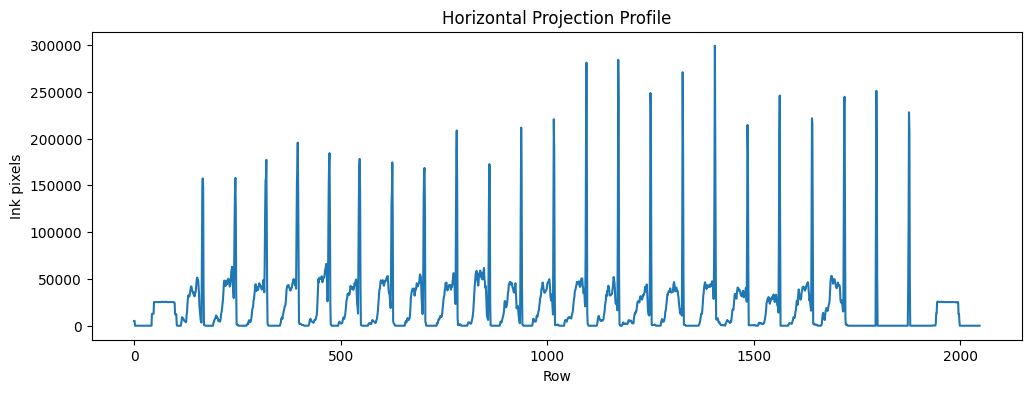

In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

IMG_PATH = "whole image/WhatsApp Image 2026-04-13 at 12.40.53.jpeg"
OUT_DIR   = "cropped image to lines/attempt1"
os.makedirs(OUT_DIR, exist_ok=True)

img   = cv2.imread(IMG_PATH)
gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Row-wise sum of ink pixels
row_sums = np.sum(binary, axis=1)

plt.figure(figsize=(12, 4))
plt.plot(row_sums)
plt.title("Horizontal Projection Profile")
plt.xlabel("Row")
plt.ylabel("Ink pixels")
plt.show()

Found 25 lines


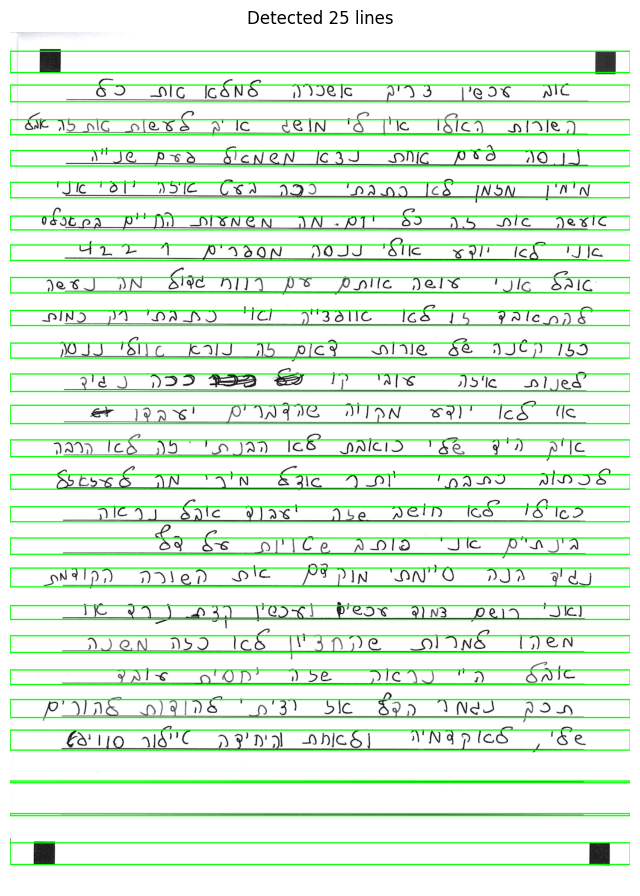

In [2]:
# Find valleys (gaps between lines)
threshold = row_sums.max() * 0.05
in_line   = row_sums > threshold

lines = []
start = None
for i, val in enumerate(in_line):
    if val and start is None:
        start = i
    elif not val and start is not None:
        lines.append((start, i))
        start = None
if start is not None:
    lines.append((start, len(in_line)))

MIN_GAP = 10
merged = [lines[0]]
for s, e in lines[1:]:
    if s - merged[-1][1] < MIN_GAP:
        merged[-1] = (merged[-1][0], e)
    else:
        merged.append((s, e))

print(f"Found {len(merged)} lines")

vis = img.copy()
for s, e in merged:
    cv2.rectangle(vis, (0, s), (img.shape[1], e), (0, 255, 0), 2)
plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"Detected {len(merged)} lines")
plt.axis("off")
plt.show()

In [3]:
PADDING = 5
for i, (s, e) in enumerate(merged):
    y1 = max(0, s - PADDING)
    y2 = min(img.shape[0], e + PADDING)
    crop = img[y1:y2, :]
    out_path = os.path.join(OUT_DIR, f"line_{i+1:02d}.jpg")
    cv2.imwrite(out_path, crop)
    print(f"Saved {out_path}  ({crop.shape[0]}x{crop.shape[1]})")

Saved cropped image to lines/attempt1\line_01.jpg  (61x1486)
Saved cropped image to lines/attempt1\line_02.jpg  (50x1486)
Saved cropped image to lines/attempt1\line_03.jpg  (46x1486)
Saved cropped image to lines/attempt1\line_04.jpg  (47x1486)
Saved cropped image to lines/attempt1\line_05.jpg  (47x1486)
Saved cropped image to lines/attempt1\line_06.jpg  (43x1486)
Saved cropped image to lines/attempt1\line_07.jpg  (47x1486)
Saved cropped image to lines/attempt1\line_08.jpg  (47x1486)
Saved cropped image to lines/attempt1\line_09.jpg  (46x1486)
Saved cropped image to lines/attempt1\line_10.jpg  (46x1486)
Saved cropped image to lines/attempt1\line_11.jpg  (52x1486)
Saved cropped image to lines/attempt1\line_12.jpg  (54x1486)
Saved cropped image to lines/attempt1\line_13.jpg  (50x1486)
Saved cropped image to lines/attempt1\line_14.jpg  (45x1486)
Saved cropped image to lines/attempt1\line_15.jpg  (46x1486)
Saved cropped image to lines/attempt1\line_16.jpg  (49x1486)
Saved cropped image to l

---
## Attempt 2 - Morphological Dilation + Contours
Dilate ink horizontally so each text line becomes one big blob, then find bounding boxes.

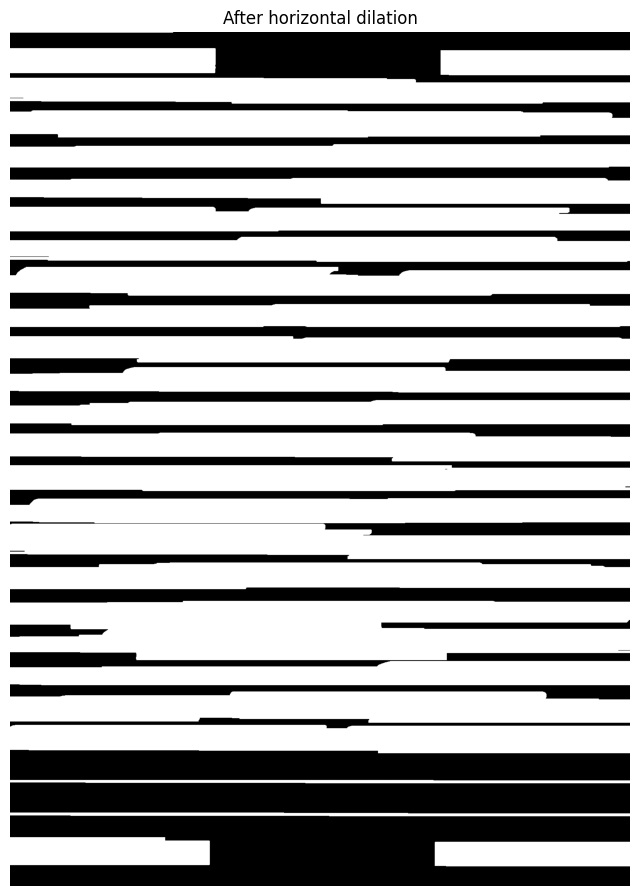

In [4]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

IMG_PATH = "whole image/WhatsApp Image 2026-04-13 at 12.40.53.jpeg"
OUT_DIR   = "cropped image to lines/attempt2"
os.makedirs(OUT_DIR, exist_ok=True)

img   = cv2.imread(IMG_PATH)
gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Wide horizontal kernel merges all words in a line into one blob
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (img.shape[1] // 2, 5))
dilated = cv2.dilate(binary, kernel, iterations=1)

plt.figure(figsize=(8, 12))
plt.imshow(dilated, cmap="gray")
plt.title("After horizontal dilation")
plt.axis("off")
plt.show()

Found 27 line regions


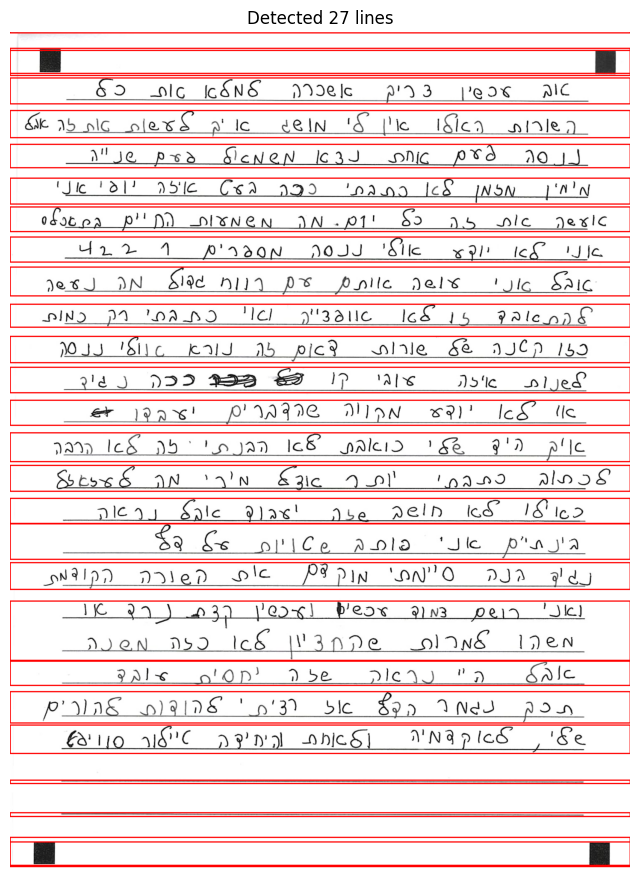

In [5]:
contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

boxes = [cv2.boundingRect(c) for c in contours]
boxes = sorted(boxes, key=lambda b: b[1])

print(f"Found {len(boxes)} line regions")

vis = img.copy()
for x, y, w, h in boxes:
    cv2.rectangle(vis, (0, y), (img.shape[1], y + h), (0, 0, 255), 2)
plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"Detected {len(boxes)} lines")
plt.axis("off")
plt.show()

In [6]:
PADDING = 5
for i, (x, y, w, h) in enumerate(boxes):
    y1 = max(0, y - PADDING)
    y2 = min(img.shape[0], y + h + PADDING)
    crop = img[y1:y2, :]
    out_path = os.path.join(OUT_DIR, f"line_{i+1:02d}.jpg")
    cv2.imwrite(out_path, crop)
    print(f"Saved {out_path}  ({crop.shape[0]}x{crop.shape[1]})")

Saved cropped image to lines/attempt2\line_01.jpg  (9x1486)
Saved cropped image to lines/attempt2\line_02.jpg  (70x1486)
Saved cropped image to lines/attempt2\line_03.jpg  (70x1486)
Saved cropped image to lines/attempt2\line_04.jpg  (72x1486)
Saved cropped image to lines/attempt2\line_05.jpg  (75x1486)
Saved cropped image to lines/attempt2\line_06.jpg  (66x1486)
Saved cropped image to lines/attempt2\line_07.jpg  (72x1486)
Saved cropped image to lines/attempt2\line_08.jpg  (69x1486)
Saved cropped image to lines/attempt2\line_09.jpg  (70x1486)
Saved cropped image to lines/attempt2\line_10.jpg  (79x1486)
Saved cropped image to lines/attempt2\line_11.jpg  (65x1486)
Saved cropped image to lines/attempt2\line_12.jpg  (73x1486)
Saved cropped image to lines/attempt2\line_13.jpg  (71x1486)
Saved cropped image to lines/attempt2\line_14.jpg  (70x1486)
Saved cropped image to lines/attempt2\line_15.jpg  (79x1486)
Saved cropped image to lines/attempt2\line_16.jpg  (72x1486)
Saved cropped image to li

---
## Attempt 3 - Smoothed Projection with Gaussian Filter
Same idea as Attempt 1 but smoothing the projection curve first avoids false splits from noise, ascenders, or descenders.

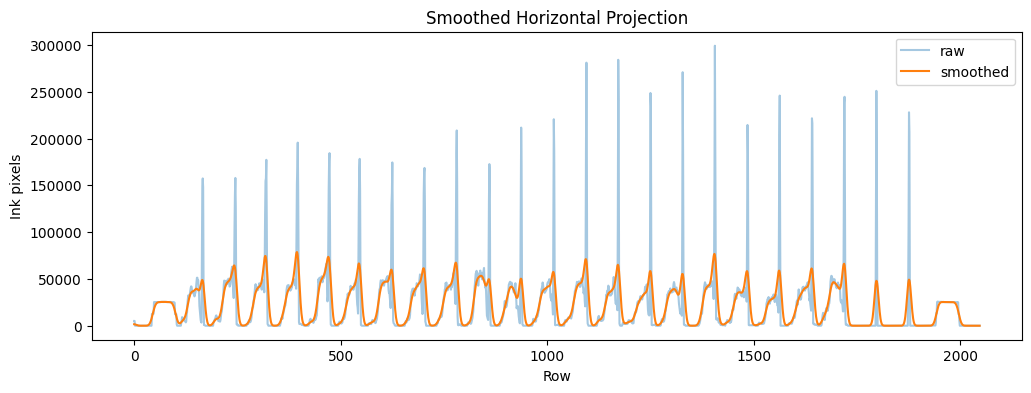

In [7]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

IMG_PATH = "whole image/WhatsApp Image 2026-04-13 at 12.40.53.jpeg"
OUT_DIR   = "cropped image to lines/attempt3"
os.makedirs(OUT_DIR, exist_ok=True)

img   = cv2.imread(IMG_PATH)
gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

row_sums = np.sum(binary, axis=1).astype(float)
smoothed = gaussian_filter1d(row_sums, sigma=5)

plt.figure(figsize=(12, 4))
plt.plot(row_sums, alpha=0.4, label="raw")
plt.plot(smoothed, label="smoothed")
plt.legend()
plt.title("Smoothed Horizontal Projection")
plt.xlabel("Row")
plt.ylabel("Ink pixels")
plt.show()

Found 25 lines


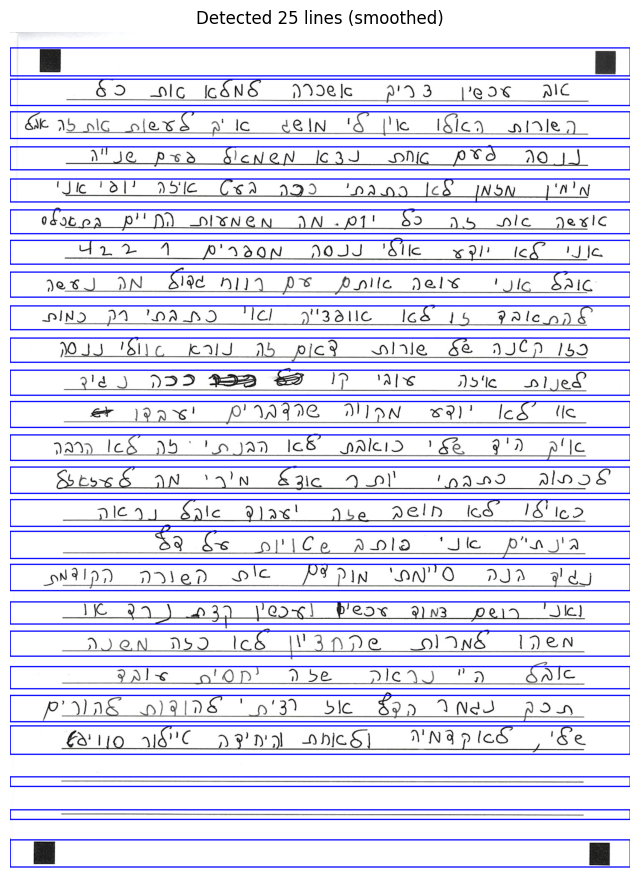

In [8]:
threshold = smoothed.max() * 0.05
in_line   = smoothed > threshold

lines = []
start = None
for i, val in enumerate(in_line):
    if val and start is None:
        start = i
    elif not val and start is not None:
        lines.append((start, i))
        start = None
if start is not None:
    lines.append((start, len(in_line)))

MIN_GAP = 8
merged = [lines[0]]
for s, e in lines[1:]:
    if s - merged[-1][1] < MIN_GAP:
        merged[-1] = (merged[-1][0], e)
    else:
        merged.append((s, e))

print(f"Found {len(merged)} lines")

vis = img.copy()
for s, e in merged:
    cv2.rectangle(vis, (0, s), (img.shape[1], e), (255, 0, 0), 2)
plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"Detected {len(merged)} lines (smoothed)")
plt.axis("off")
plt.show()

In [9]:
PADDING = 5
for i, (s, e) in enumerate(merged):
    y1 = max(0, s - PADDING)
    y2 = min(img.shape[0], e + PADDING)
    crop = img[y1:y2, :]
    out_path = os.path.join(OUT_DIR, f"line_{i+1:02d}.jpg")
    cv2.imwrite(out_path, crop)
    print(f"Saved {out_path}  ({crop.shape[0]}x{crop.shape[1]})")

Saved cropped image to lines/attempt3\line_01.jpg  (77x1486)
Saved cropped image to lines/attempt3\line_02.jpg  (73x1486)
Saved cropped image to lines/attempt3\line_03.jpg  (74x1486)
Saved cropped image to lines/attempt3\line_04.jpg  (65x1486)
Saved cropped image to lines/attempt3\line_05.jpg  (65x1486)
Saved cropped image to lines/attempt3\line_06.jpg  (67x1486)
Saved cropped image to lines/attempt3\line_07.jpg  (67x1486)
Saved cropped image to lines/attempt3\line_08.jpg  (70x1486)
Saved cropped image to lines/attempt3\line_09.jpg  (67x1486)
Saved cropped image to lines/attempt3\line_10.jpg  (68x1486)
Saved cropped image to lines/attempt3\line_11.jpg  (70x1486)
Saved cropped image to lines/attempt3\line_12.jpg  (72x1486)
Saved cropped image to lines/attempt3\line_13.jpg  (71x1486)
Saved cropped image to lines/attempt3\line_14.jpg  (73x1486)
Saved cropped image to lines/attempt3\line_15.jpg  (74x1486)
Saved cropped image to lines/attempt3\line_16.jpg  (75x1486)
Saved cropped image to l